In [135]:
from sklearn.datasets import make_regression

In [136]:
X,y = make_regression(
    n_samples=1000,
    n_features=5,
    noise=0,
    random_state=0,
)

In [137]:
from sklearn.preprocessing import  MinMaxScaler

scaler  = MinMaxScaler()


X_scaled = scaler.fit_transform(X)

In [138]:
age = (X_scaled[:,0] * 62 + 18).astype(int)
bmi = X_scaled[:,1] * 25 + 15
bp = X_scaled[:,2]*80 + 90
prev_adm = (X_scaled[:,3] * 10).astype(int)
severity = (X_scaled[:,4] * 9 + 1).astype(int)


In [139]:
import numpy as np

staying_days = (
    0.05 * age +
    0.2 * bmi +
    0.08 * bp +
    1.5 * prev_adm +
    2.5 * severity +
    np.random.normal(0, 3, 1000)
)

In [140]:
staying_days = np.clip(staying_days, 1, None).round().astype(int)

In [141]:
import pandas as pd

df = pd.DataFrame({
    "Age": age,
    "BMI": bmi.round(1),
    "Blood Pressure": bp.round(1),
    "Previous Admissions": prev_adm,
    "Severity Score": severity,
    "Staying Days": staying_days
})

In [142]:
df

,Age,BMI,Blood Pressure,Previous Admissions,Severity Score,Staying Days
0,47,33.5,116.4,6,8,50
1,42,27.2,125.9,3,7,35
2,53,22.0,142.6,1,4,30
3,30,23.1,120.9,6,6,41
4,52,28.2,134.1,4,3,34
...,...,...,...,...,...,...
995,37,26.0,125.9,6,4,34
996,58,24.0,140.1,4,5,39
997,35,27.4,115.9,4,4,31
998,52,28.2,136.3,2,8,42


In [143]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1000 non-null   int64  
 1   BMI                  1000 non-null   float64
 2   Blood Pressure       1000 non-null   float64
 3   Previous Admissions  1000 non-null   int64  
 4   Severity Score       1000 non-null   int64  
 5   Staying Days         1000 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 47.0 KB


In [144]:
df.describe()

,Age,BMI,Blood Pressure,Previous Admissions,Severity Score,Staying Days
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,49.513000,26.189100,131.517100,4.330000,5.32700,37.990000
std,9.351646,3.627745,11.233078,1.715238,1.50942,5.689312
min,18.000000,15.000000,90.000000,0.000000,1.00000,19.000000
25%,43.000000,23.600000,123.900000,3.000000,4.00000,34.000000
50%,50.000000,26.100000,131.600000,4.000000,5.00000,38.000000
75%,55.000000,28.700000,139.100000,5.000000,6.00000,42.000000
max,80.000000,40.000000,170.000000,10.000000,10.00000,55.000000


In [145]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split( df[["Age","BMI" ,"Blood Pressure"  , "Previous Admissions" , "Severity Score"]], df["Staying Days"], random_state=0)

In [146]:
from sklearn.ensemble import RandomForestRegressor


forest = RandomForestRegressor(n_estimators=100, random_state=0)
forest.fit(X_train ,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [147]:
y_pred = forest.predict(X_test)

In [148]:
from sklearn.metrics import r2_score , root_mean_squared_error,mean_squared_error,mean_absolute_error

r2 = r2_score(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)



print("R2:",r2)
print("RMSE:",rmse)
print("MAE:",mae)
print("MSE:",mse)



R2: 0.6520136173895337
RMSE: 3.3071666423087906
MAE: 2.64576
MSE: 10.9373512


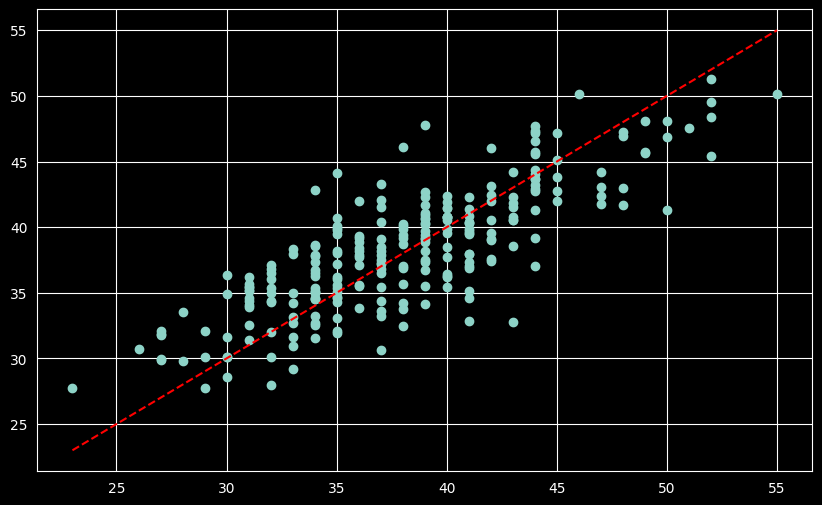

In [151]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(y_test,y_pred)
plt.plot([y_test.min() , y_test.max()] , [y_test.min() , y_test.max()] , linestyle='--' , color='r')



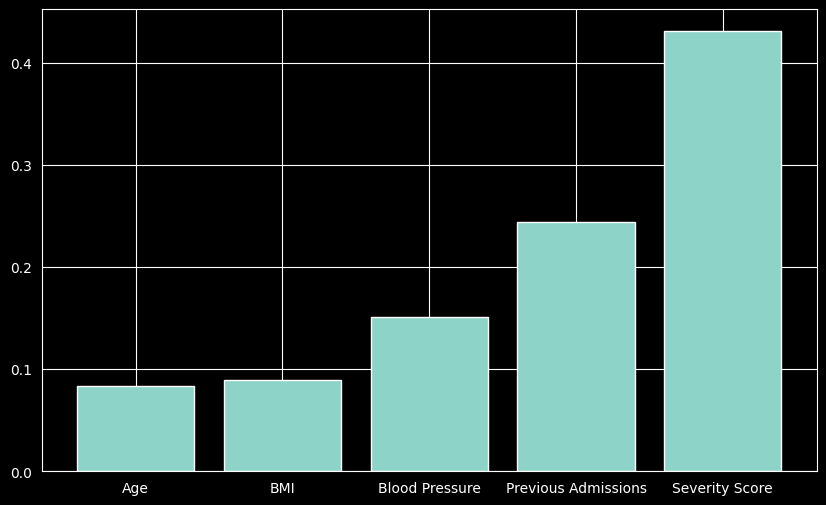

In [150]:
plt.figure(figsize=(10,6))
plt.bar(X_train.columns,forest.feature_importances_)
plt.show()